# Aethernet Orchestrator - Diagnostic Blueprint
This notebook simulates the entire Aethernet Orchestrator pipeline, validating data flow and conditional routing.

In [1]:
from typing import TypedDict, Annotated, Sequence
import operator
from langgraph.graph import StateGraph, END

# Cell 1: System Imports & State Definition
class AgentState(TypedDict):
    input_data: str
    input_type: str
    original_transcript: str
    bullet_points: str
    final_lesson: str
    execution_error: str
    code_language: str
    is_vision_only: bool
    is_code_request: bool

print("Cell 1 Executed: Imports and State Defined.")

Cell 1 Executed: Imports and State Defined.


In [2]:
# Cell 2: The Pipeline Architecture (Mermaid Diagram)
from IPython.display import display, Markdown

mermaid_code = """
```mermaid
graph TD
    %% Cluster A: Multimodal Reasoning (Pipeline A)
    subgraph Cluster A: Multimodal Reasoning
        T[Text Upload]
        P[PDF Upload]
        I[Image Upload]
        
        Extract[Extraction: PyMuPDF / LLaVA]
        Te[Teacher Node: Qwen 2.5]
        R[Reviewer Node]
        EndA[END]
        
        T --> Extract
        P --> Extract
        I --> Extract
        Extract --> Te
        Te --> R
        R --> EndA
    end

    %% Cluster B: Autonomous Code Execution (Pipeline B)
    subgraph Cluster B: Autonomous Code Execution
        C[Editor Input: Run Code]
        MD[Manual Debug Button]
        
        E2B[E2B Sandbox Node]
        Debug[DeepSeek Debugger Node]
        ErrorCheck{execution_error?}
        EndB[END]
        
        C --> E2B
        MD --> Debug
        
        E2B --> ErrorCheck
        ErrorCheck -- Yes --> EndB
        ErrorCheck -- No --> EndB
        
        Debug --> E2B
    end
```
"""

display(Markdown(mermaid_code))
print("Cell 2 Executed: Architecture Diagram Rendered.")


```mermaid
graph TD
    %% Cluster A: Multimodal Reasoning (Pipeline A)
    subgraph Cluster A: Multimodal Reasoning
        T[Text Upload]
        P[PDF Upload]
        I[Image Upload]
        
        Extract[Extraction: PyMuPDF / LLaVA]
        Te[Teacher Node: Qwen 2.5]
        R[Reviewer Node]
        EndA[END]
        
        T --> Extract
        P --> Extract
        I --> Extract
        Extract --> Te
        Te --> R
        R --> EndA
    end

    %% Cluster B: Autonomous Code Execution (Pipeline B)
    subgraph Cluster B: Autonomous Code Execution
        C[Editor Input: Run Code]
        MD[Manual Debug Button]
        
        E2B[E2B Sandbox Node]
        Debug[DeepSeek Debugger Node]
        ErrorCheck{execution_error?}
        EndB[END]
        
        C --> E2B
        MD --> Debug
        
        E2B --> ErrorCheck
        ErrorCheck -- Yes --> EndB
        ErrorCheck -- No --> EndB
        
        Debug --> E2B
    end
```


Cell 2 Executed: Architecture Diagram Rendered.


In [3]:
# Cell 4: Data Flow Audit
def print_state_audit(state: AgentState):
    print("\n" + "-"*40)
    print("📋 STATE AUDIT")
    print("-" * 40)
    for k, v in state.items():
        val_str = str(v)
        if len(val_str) > 50:
            val_str = val_str[:47] + "..."
        print(f"{k.ljust(20)} : {val_str}")
    print("-" * 40 + "\n")

print("Cell 4 Executed: State Audit Utility Defined.")

Cell 4 Executed: State Audit Utility Defined.


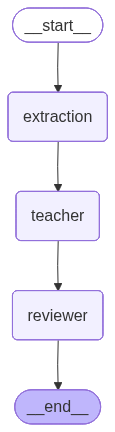

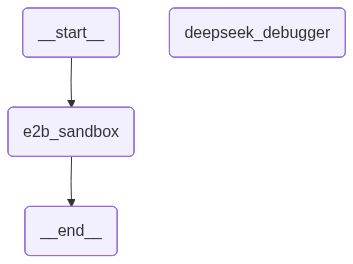

Cell 3 Executed: Pipeline Nodes and Simulation Function Defined.


In [4]:
# Cell 3: Mock Pipeline Simulation
def extraction_node(state: AgentState) -> AgentState:
    print("--> [Cluster A] Processing extraction (PyMuPDF / LLaVA)...")
    state["original_transcript"] = f"Processed content from {state['input_type']}"
    return state

def teacher_node(state: AgentState) -> AgentState:
    print("--> [Cluster A] Teacher Node: Creating final lesson (Qwen 2.5)...")
    state["final_lesson"] = "Welcome to the lesson! Today we cover..."
    return state

def reviewer_node(state: AgentState) -> AgentState:
    print("--> [Cluster A] Reviewer Node: Reviewing output...")
    return state

def e2b_sandbox_node(state: AgentState) -> AgentState:
    print("--> [Cluster B] E2B Sandbox Node: Executing code...")
    if state["input_data"] == "trigger_error":
        print("    [!] Execution failed!")
        state["execution_error"] = "SyntaxError: invalid syntax"
    else:
        print("    [+] Execution succeeded!")
        state["execution_error"] = ""
    return state

def deepseek_debugger_node(state: AgentState) -> AgentState:
    print("--> [Cluster B] DeepSeek Debugger Node: Fixing code...")
    state["execution_error"] = ""
    state["input_data"] = "fixed_code"
    return state

# Pipeline A Graph
pipeline_a = StateGraph(AgentState)
pipeline_a.add_node("extraction", extraction_node)
pipeline_a.add_node("teacher", teacher_node)
pipeline_a.add_node("reviewer", reviewer_node)
pipeline_a.set_entry_point("extraction")
pipeline_a.add_edge("extraction", "teacher")
pipeline_a.add_edge("teacher", "reviewer")
pipeline_a.add_edge("reviewer", END)
app_a = pipeline_a.compile()

# Pipeline B Graph (Debug Loop only triggered manually)
pipeline_b = StateGraph(AgentState)
pipeline_b.add_node("e2b_sandbox", e2b_sandbox_node)
pipeline_b.add_node("deepseek_debugger", deepseek_debugger_node)
pipeline_b.set_entry_point("e2b_sandbox")
pipeline_b.add_edge("e2b_sandbox", END)
pipeline_b.add_edge("deepseek_debugger", "e2b_sandbox")
app_b = pipeline_b.compile()

from IPython.display import display, Image
try:
    display(Image(app_a.get_graph().draw_mermaid_png()))
    display(Image(app_b.get_graph().draw_mermaid_png()))
except Exception:
    pass

def run_mock_pipeline_a(input_data: str, input_type: str):
    print(f"\n{'='*50}\nStarting Pipeline A Simulation: {input_type.upper()}\n{'='*50}")
    
    initial_state = {
        "input_data": input_data,
        "input_type": input_type,
        "original_transcript": "",
        "bullet_points": "",
        "final_lesson": "",
        "execution_error": "",
        "code_language": "python",
        "is_vision_only": input_type == "image",
        "is_code_request": False
    }
    
    for event in app_a.stream(initial_state):
        for key, value in event.items():
            print(f"Finished {key}")
            print_state_audit(value)

def run_mock_pipeline_b(input_data: str, is_debug: bool = False):
    print(f"\n{'='*50}\nStarting Pipeline B Simulation: {'DEBUG' if is_debug else 'EXECUTE'}\n{'='*50}")
    
    initial_state = {
        "input_data": input_data,
        "input_type": "code",
        "original_transcript": "",
        "bullet_points": "",
        "final_lesson": "",
        "execution_error": "",
        "code_language": "python",
        "is_vision_only": False,
        "is_code_request": True
    }
    
    if is_debug:
        state = initial_state.copy()
        state = deepseek_debugger_node(state)
        state = e2b_sandbox_node(state)
        print("Finished Debug Loop")
        print_state_audit(state)
    else:
        for event in app_b.stream(initial_state):
            for key, value in event.items():
                print(f"Finished {key}")
                print_state_audit(value)

print("Cell 3 Executed: Pipeline Nodes and Simulation Function Defined.")


In [5]:
# Simulate Pipeline A for Multimodal Inputs
run_mock_pipeline_a("image_data_base64", "image")
run_mock_pipeline_a("pdf_text_data", "pdf")
run_mock_pipeline_a("youtube_transcript", "video")

# Simulate Pipeline B for Execution and Debug
run_mock_pipeline_b("valid_code", is_debug=False)
run_mock_pipeline_b("trigger_error", is_debug=True)



Starting Pipeline A Simulation: IMAGE
--> [Cluster A] Processing extraction (PyMuPDF / LLaVA)...
Finished extraction

----------------------------------------
📋 STATE AUDIT
----------------------------------------
input_data           : image_data_base64
input_type           : image
original_transcript  : Processed content from image
bullet_points        : 
final_lesson         : 
execution_error      : 
code_language        : python
is_vision_only       : True
is_code_request      : False
----------------------------------------

--> [Cluster A] Teacher Node: Creating final lesson (Qwen 2.5)...
Finished teacher

----------------------------------------
📋 STATE AUDIT
----------------------------------------
input_data           : image_data_base64
input_type           : image
original_transcript  : Processed content from image
bullet_points        : 
final_lesson         : Welcome to the lesson! Today we cover...
execution_error      : 
code_language        : python
is_vision_only    